In [2]:
from scipy.io import arff
import pandas as pd

# โหลดไฟล์ .arff
data, meta = arff.loadarff('Data/weather.numeric.arff')

# แปลงเป็น Pandas DataFrame
df = pd.DataFrame(data)

# แสดงตัวอย่างข้อมูล
df


,outlook,temperature,humidity,windy,play
0,b'sunny',85.0,85.0,b'FALSE',b'no'
1,b'sunny',80.0,90.0,b'TRUE',b'no'
2,b'overcast',83.0,86.0,b'FALSE',b'yes'
3,b'rainy',70.0,96.0,b'FALSE',b'yes'
4,b'rainy',68.0,80.0,b'FALSE',b'yes'
5,b'rainy',65.0,70.0,b'TRUE',b'no'
6,b'overcast',64.0,65.0,b'TRUE',b'yes'
7,b'sunny',72.0,95.0,b'FALSE',b'no'
8,b'sunny',69.0,70.0,b'FALSE',b'yes'
9,b'rainy',75.0,80.0,b'FALSE',b'yes'


In [3]:
df = df.applymap(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

df

C:\Users\Pond0\AppData\Local\Temp\ipykernel_28948\3145443094.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)


,outlook,temperature,humidity,windy,play
0,sunny,85.0,85.0,FALSE,no
1,sunny,80.0,90.0,TRUE,no
2,overcast,83.0,86.0,FALSE,yes
3,rainy,70.0,96.0,FALSE,yes
4,rainy,68.0,80.0,FALSE,yes
5,rainy,65.0,70.0,TRUE,no
6,overcast,64.0,65.0,TRUE,yes
7,sunny,72.0,95.0,FALSE,no
8,sunny,69.0,70.0,FALSE,yes
9,rainy,75.0,80.0,FALSE,yes


In [4]:
duplicate_df = df[df.duplicated()]
print("Number of duplicate rows", duplicate_df.shape)

Number of duplicate rows (0, 5)


In [5]:
from sklearn.preprocessing import LabelEncoder

le_Outlook = LabelEncoder()
le_Windy = LabelEncoder()
le_Play = LabelEncoder()

df['outlook_en'] = le_Outlook.fit_transform(df['outlook'])
df['windy_en'] = le_Windy.fit_transform(df['windy'])
df['play_en'] = le_Play.fit_transform(df['play'])

print(dict(enumerate(le_Outlook.classes_)))
print(dict(enumerate(le_Windy.classes_)))
print(dict(enumerate(le_Play.classes_)))

{0: 'overcast', 1: 'rainy', 2: 'sunny'}
{0: 'FALSE', 1: 'TRUE'}
{0: 'no', 1: 'yes'}


In [6]:
df

,outlook,temperature,humidity,windy,play,outlook_en,windy_en,play_en
0,sunny,85.0,85.0,FALSE,no,2,0,0
1,sunny,80.0,90.0,TRUE,no,2,1,0
2,overcast,83.0,86.0,FALSE,yes,0,0,1
3,rainy,70.0,96.0,FALSE,yes,1,0,1
4,rainy,68.0,80.0,FALSE,yes,1,0,1
5,rainy,65.0,70.0,TRUE,no,1,1,0
6,overcast,64.0,65.0,TRUE,yes,0,1,1
7,sunny,72.0,95.0,FALSE,no,2,0,0
8,sunny,69.0,70.0,FALSE,yes,2,0,1
9,rainy,75.0,80.0,FALSE,yes,1,0,1


In [7]:
df = df.drop(['outlook', 'windy', 'play'], axis=1)

df

,temperature,humidity,outlook_en,windy_en,play_en
0,85.0,85.0,2,0,0
1,80.0,90.0,2,1,0
2,83.0,86.0,0,0,1
3,70.0,96.0,1,0,1
4,68.0,80.0,1,0,1
5,65.0,70.0,1,1,0
6,64.0,65.0,0,1,1
7,72.0,95.0,2,0,0
8,69.0,70.0,2,0,1
9,75.0,80.0,1,0,1


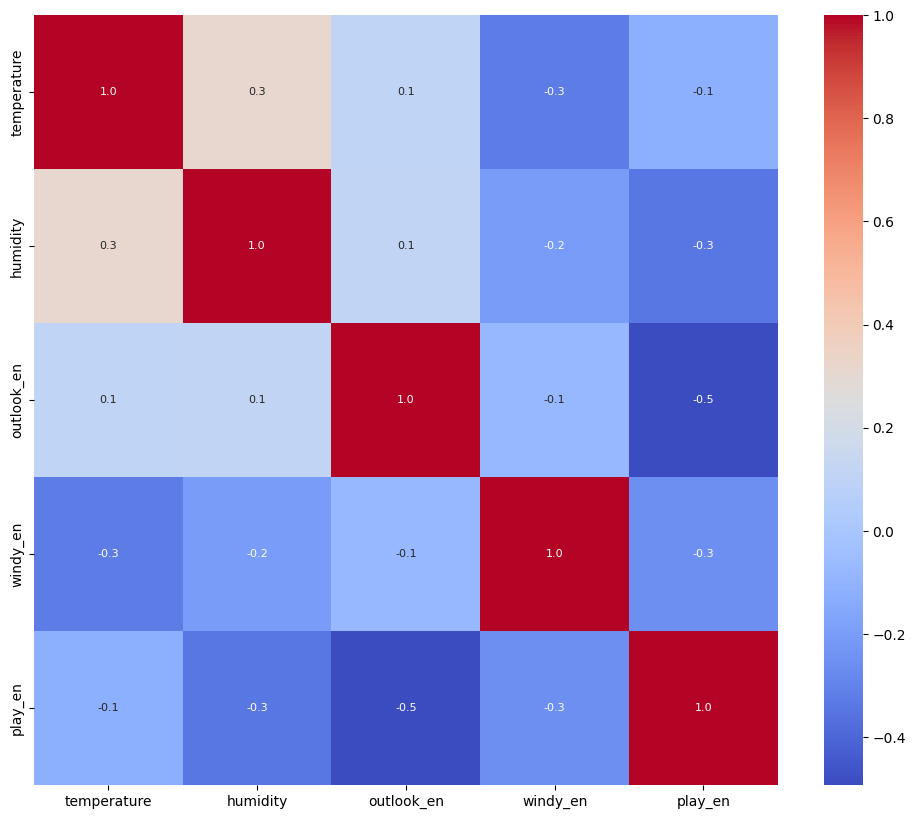

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr()
plt.figure(figsize=(12, 10))  # Adjust the width and height as needed

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',fmt=".1f", annot_kws={"size": 8})
plt.show()

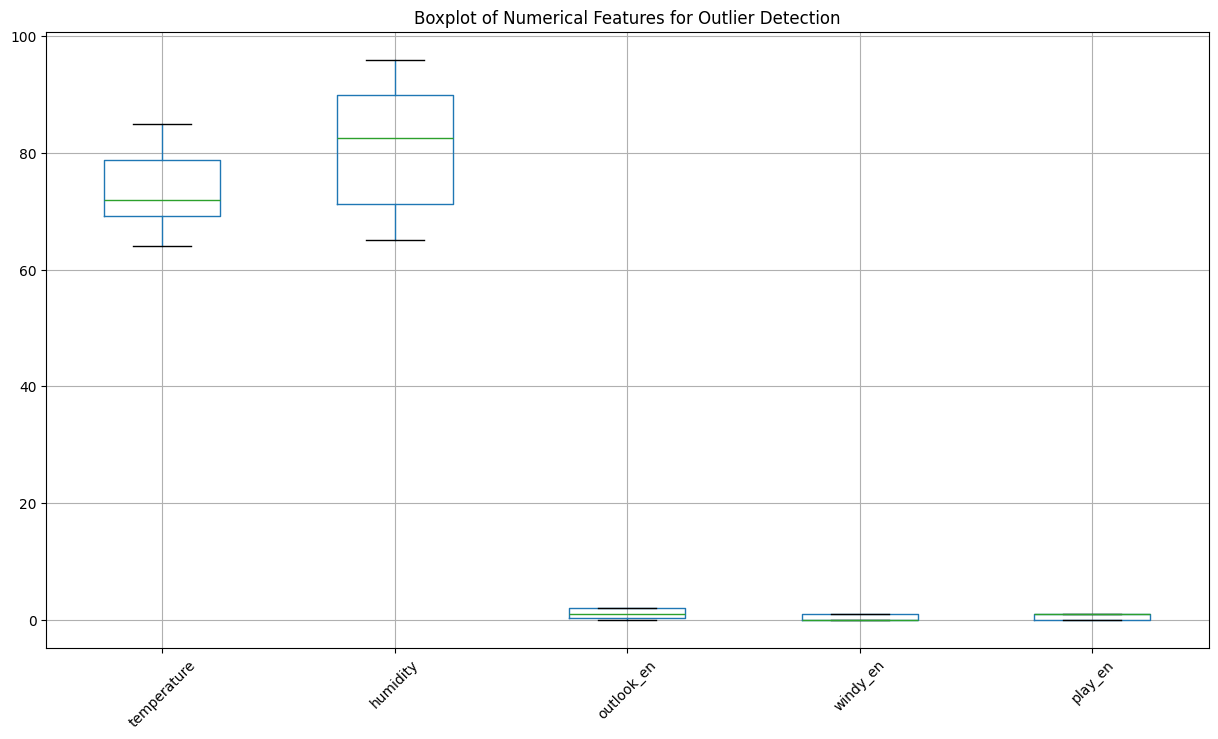

In [9]:
plt.figure(figsize=(15, 8))
df.boxplot(rot=45)
plt.title("Boxplot of Numerical Features for Outlier Detection")
plt.show()

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df_x = df.drop(['play_en'], axis=1)

df_y = df['play_en']

df_x = df_x.to_numpy()

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.naive_bayes import GaussianNB  # ไม่มีเวอร์ชัน Regression ที่ตรงตัว
from sklearn.neighbors import KNeighborsRegressor


from sklearn.metrics import accuracy_score



# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.2, random_state=42) # You can adjust test_size and random_state


# Define a dictionary of models to evaluate
models = {
    "LinearRegression": LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "RandomForestRegressor": RandomForestRegressor(),
    "SVR": SVR(),
    "KNeighborsRegressor": KNeighborsRegressor()
}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    MAE = mean_absolute_error(y_test, y_pred)
    MSE = mean_squared_error(y_test, y_pred)
    R2 = r2_score(y_test, y_pred)
    print(f"{name} MAE: {MAE} MSE: {MSE} R-Squared: {R2}")

LinearRegression MAE: 0.5374940262027121 MSE: 0.401465954066026 R-Squared: -0.8065967932971168
DecisionTreeRegressor MAE: 0.6666666666666666 MSE: 0.6666666666666666 R-Squared: -1.9999999999999996
RandomForestRegressor MAE: 0.5499999999999999 MSE: 0.3953666666666667 R-Squared: -0.77915
SVR MAE: 0.39031218013280666 MSE: 0.26356400919150674 R-Squared: -0.18603804136178037
KNeighborsRegressor MAE: 0.39999999999999997 MSE: 0.18666666666666668 R-Squared: 0.16000000000000003


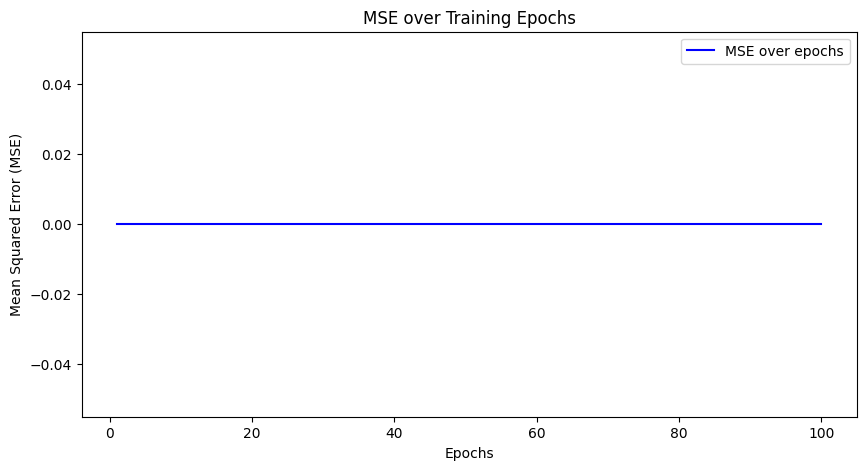

Epoch 10: MAE = 0.0000 - MSE = 0.0000 - MSEE = 0.0000 - C = 0.0000
Epoch 20: MAE = 0.0000 - MSE = 0.0000 - MSEE = 0.0000 - C = 0.0000
Epoch 30: MAE = 0.0000 - MSE = 0.0000 - MSEE = 0.0000 - C = 0.0000
Epoch 40: MAE = 0.0000 - MSE = 0.0000 - MSEE = 0.0000 - C = 0.0000
Epoch 50: MAE = 0.0000 - MSE = 0.0000 - MSEE = 0.0000 - C = 0.0000
Epoch 60: MAE = 0.0000 - MSE = 0.0000 - MSEE = 0.0000 - C = 0.0000
Epoch 70: MAE = 0.0000 - MSE = 0.0000 - MSEE = 0.0000 - C = 0.0000
Epoch 80: MAE = 0.0000 - MSE = 0.0000 - MSEE = 0.0000 - C = 0.0000
Epoch 90: MAE = 0.0000 - MSE = 0.0000 - MSEE = 0.0000 - C = 0.0000
Epoch 100: MAE = 0.0000 - MSE = 0.0000 - MSEE = 0.0000 - C = 0.0000
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.datasets import make_regression

# สร้างตัวเรียนรู้แบบ Gradient Boosting
gbr = GradientBoostingRegressor(n_estimators=10, learning_rate=1, max_depth=3, random_state=42)

# เก็บค่าความสูญเสียในแต่ละรอบ
mae_values = []
mse_values = []
msee_values = []
equations_sse = []
C_values = []
m1_vals = []
m2_vals = []
m3_vals = []
m4_vals = []
equations = []

# ฝึกโมเดลและบันทึกค่า error และค่าคงที่ C
for epoch in range(1, 101):  # จำนวนรอบที่ฝึก
    gbr.n_estimators = epoch  # ปรับจำนวน estimators ตามรอบ
    gbr.fit(df_x, df_y)
    y_pred = gbr.predict(df_x)
    
    mse = mean_squared_error(df_y, y_pred)
    mae = mean_absolute_error(df_y, y_pred)
    msee = np.mean((df_y - y_pred) ** 2)  # คำนวณ MSEE ใหม่
    C = np.mean(df_y - y_pred)  # ค่า C = ค่าเฉลี่ยของ residuals
    mse_values.append(mse)
    mae_values.append(mae)
    msee_values.append(msee)
    C_values.append(C)

    coef_approx = np.linalg.lstsq(df_x[:, :4], y_pred, rcond=None)[0]
    m1, m2, m3, m4 = coef_approx[0], coef_approx[1], coef_approx[2], coef_approx[3]
    m1_vals.append(m1)
    m2_vals.append(m2)
    m3_vals.append(m3)
    m4_vals.append(m4)
    
    if epoch % 10 == 0:
        equations_sse.append(f"Epoch {epoch}: MAE = {mae:.4f} - MSE = {mse:.4f} - MSEE = {msee:.4f} - C = {C:.4f}")
        equations.append(f"     y = {m1:.4f}x1 + {m2:.4f}x2 + {m3:.4f}x3 + {m4:.4f}x4 + {C:.4f}")

# Plot ค่า MSE ในแต่ละ epoch
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(mse_values) + 1), mse_values, label="MSE over epochs", color="blue")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("MSE over Training Epochs")
plt.legend()
plt.show()

# แสดงค่า C ที่บันทึกไว้ทุก epoch
for eq in equations_sse:
    print(eq)

for eq_sse in mse_values:
    print(eq_sse)

for eq_y in equations:
    print(eq_y)


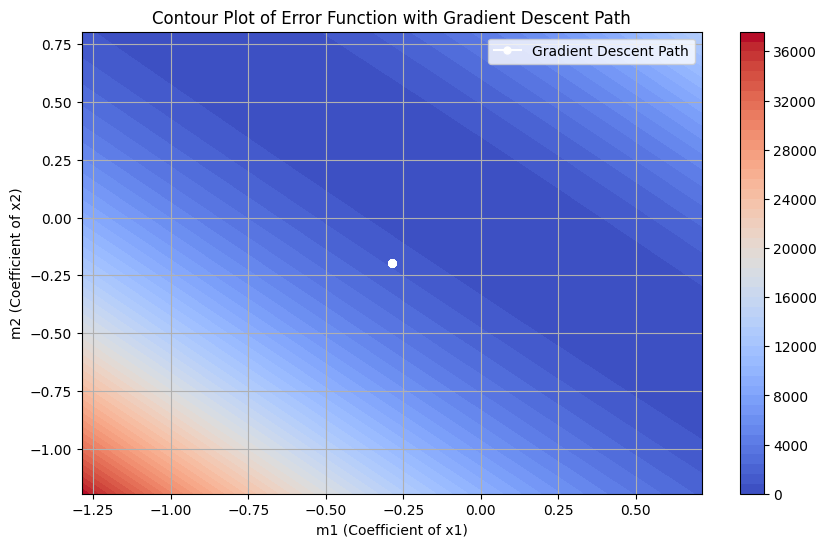

In [24]:
# Contour Plot
m1_range = np.linspace(min(m3_vals) - 1, max(m3_vals) + 1, 50)
m2_range = np.linspace(min(m4_vals) - 1, max(m4_vals) + 1, 50)
M1, M2 = np.meshgrid(m1_range, m2_range)

# คำนวณค่า Error (MSE) สำหรับแต่ละค่าใน Grid
Error = np.zeros_like(M1)
for i in range(M1.shape[0]):
    for j in range(M1.shape[1]):
        y_pred_grid = M1[i, j] * df_x[:, 0] + M2[i, j] * df_x[:, 1] + np.mean(C_values)
        Error[i, j] = np.mean((df_y - y_pred_grid) ** 2)

# Plot Contour
plt.figure(figsize=(10, 6))
contour = plt.contourf(M1, M2, Error, levels=50, cmap="coolwarm")
plt.colorbar(contour)

# Plot ตำแหน่งของค่า m1, m2 ในแต่ละรอบ
plt.plot(m3_vals, m4_vals, 'wo-', markersize=5, label="Gradient Descent Path")

plt.xlabel("m1 (Coefficient of x1)")
plt.ylabel("m2 (Coefficient of x2)")
plt.title("Contour Plot of Error Function with Gradient Descent Path")
plt.legend()
plt.grid()
plt.show()